# 01 · Equation learners: a network you can read as mathematics

**Question:** Can we learn a compact equation instead of only a useful predictor?

In lesson 00 you differentiated a network. Here we change its building blocks so its
prediction is an explicit mathematical expression. You will build a small **EQL-style**
network entirely in NumPy, check every derivative, train it, remove small connections,
and translate the fitted network back into an equation.

**Prerequisites:** lesson 00, matrix shapes, chain rule, and Python functions.
**Time:** 75–120 minutes with exercises. **Compute:** CPU, no downloaded data or GPU.
Install `python -m pip install -r learn/vector_01/requirements.txt` from the repository root,
then select that environment as your kernel. Run top to bottom from any working directory.

This is a deliberately small teaching implementation, not a reproduction of a paper's
architecture, schedule, or benchmark. Our operator set is identity, square, sine, and product.
We use NumPy so every backward operation stays visible; a framework would automate those derivatives.

**Route:** operator graphs → forward pass → gradients → sparsity → expression extraction
→ honest evaluation → failure modes. At each **Predict** prompt, guess before running.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import display, Markdown
np.set_printoptions(precision=5, suppress=True)
plt.rcParams.update({'figure.dpi': 105, 'font.size': 10, 'axes.grid': True,
                     'grid.alpha': 0.18, 'axes.spines.top': False, 'axes.spines.right': False})
BLUE, ORANGE, GREEN, RED = '#2563eb', '#d97706', '#15803d', '#dc2626'
SEED = 42
print('NumPy:', np.__version__)

NumPy: 2.3.5


## 1 · What actually makes this an equation learner?

A conventional neural network already defines a mathematical function. EQL emphasizes
operators that make a *small resulting expression* useful to inspect. Sparsity encourages
unused connections to disappear. Interpretability still depends on how complicated the
surviving expression becomes.

The original EQL work appeared in 2016 (Martius and Lampert). Its central construction
alternates learned linear combinations with mathematical operators. The 2018 EQL-Div
extension adds division and specialized training/model-selection machinery.
Our notebook omits division and uses its own compact architecture and schedule.
See the primary sources at the end for those research designs.

| Approach | What is learned? | Main structural restriction |
|---|---|---|
| Fixed feature regression | Output coefficients for precomputed features | Feature expressions are already chosen |
| Our EQL-style network | Arguments to operators **and** output coefficients | Operator slots and depth are chosen in advance |
| Discrete symbolic search | Candidate expression trees and their constants | Search grammar, budget, and scoring rule |

Learning `sin(a*x+b)` is different from choosing the coefficient of a fixed `sin(x)` feature:
$a$ and $b$ change the shape. But having a sine slot does not mean we search all possible
formulas. Architecture is an inductive bias: a preference built into the learner.

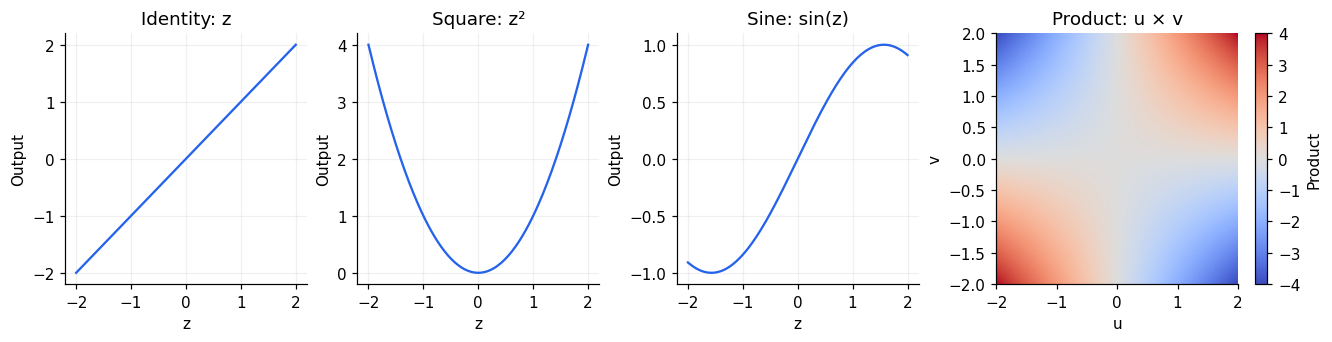

In [2]:
z = np.linspace(-2, 2, 200)
fig, axes = plt.subplots(1, 4, figsize=(12, 3), layout='constrained')
for ax, value, title in zip(axes[:3], [z, z**2, np.sin(z)], ['Identity: z', 'Square: z²', 'Sine: sin(z)']):
    ax.plot(z, value, color=BLUE); ax.set(title=title, xlabel='z', ylabel='Output')
u, v = np.meshgrid(z, z)
im = axes[3].imshow(u*v, extent=(-2,2,-2,2), origin='lower', cmap='coolwarm', aspect='auto')
axes[3].set(title='Product: u × v', xlabel='u', ylabel='v'); axes[3].grid(False)
fig.colorbar(im, ax=axes[3], label='Product')
plt.show()

## 2 · One small graph, written both ways

Our inputs are two scalar measurements $x_0,x_1$. For a batch $X\in\mathbb{R}^{N\times2}$,
first compute five learned affine arguments:

$$Z=XW+b,\qquad W\in\mathbb{R}^{2\times5},\quad b\in\mathbb{R}^{1\times5}.$$

Then four operator outputs and one linear readout:

$$H=[z_0,\ z_1^2,\ \sin(z_2),\ z_3z_4],\qquad \hat Y=Ha+c.$$

$H$ has shape $N\times4$, $a$ is $4\times1$, and $c$ is $1\times1$.
A product consumes **two** arguments, explaining the five-to-four change in width.
Every slot has a fixed operator; gradient descent changes its arguments and contribution.

For one example this is the equation:

$$\hat y=a_0(w_0^Tx+b_0)+a_1(w_1^Tx+b_1)^2
+a_2\sin(w_2^Tx+b_2)+a_3(w_3^Tx+b_3)(w_4^Tx+b_4)+c.$$

There are 20 trainable numbers. Adding another operator layer would allow deeper compositions,
such as a sine of a product. Our single layer cannot represent every composition.

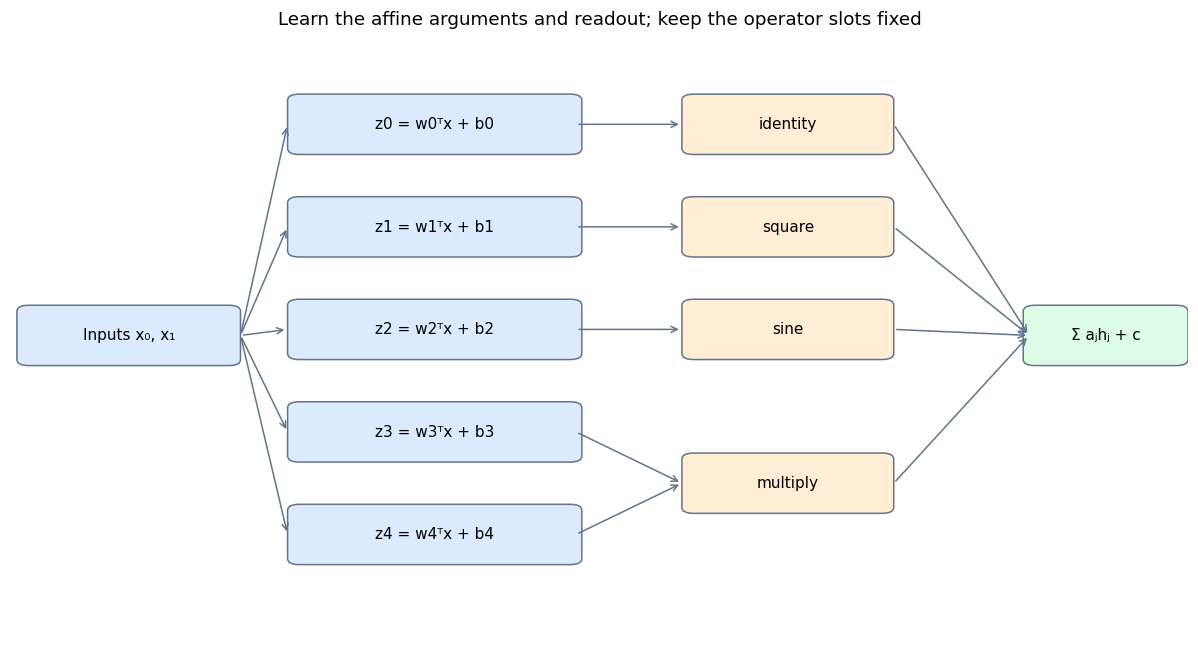

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.set(xlim=(0,1), ylim=(0,1)); ax.axis('off')
def box(x,y,label,width=0.17,color='#dbeafe'):
    ax.add_patch(FancyBboxPatch((x-width/2,y-0.04),width,0.08,boxstyle='round,pad=0.01',
                               facecolor=color,edgecolor='#64748b'))
    ax.text(x,y,label,ha='center',va='center',fontsize=10)
def arrow(x1,y1,x2,y2):
    ax.annotate('',xy=(x2,y2),xytext=(x1,y1),arrowprops={'arrowstyle':'->','color':'#64748b'})
box(.10,.5,'Inputs x₀, x₁',.17)
ys=[.85,.68,.51,.34,.17]
for j,y in enumerate(ys):
    box(.36,y,f'z{j} = w{j}ᵀx + b{j}',.23)
    arrow(.195,.5,.235,y)
for j,y,label in [(0,.85,'identity'),(1,.68,'square'),(2,.51,'sine')]:
    box(.66,y,label,.16,'#ffedd5'); arrow(.48,y,.57,y); arrow(.75,y,.865,.5)
box(.66,.255,'multiply',.16,'#ffedd5')
arrow(.48,.34,.57,.255); arrow(.48,.17,.57,.255); arrow(.75,.255,.865,.5)
box(.93,.5,'Σ aⱼhⱼ + c',.12,'#dcfce7')
ax.set_title('Learn the affine arguments and readout; keep the operator slots fixed')
plt.tight_layout(); plt.show()

## 3 · Build the forward graph and its backward pass

Use the same half-MSE as lesson 00:
$L_{fit}=\frac{1}{2N}\sum_i(\hat y_i-y_i)^2$.
We will also encourage small parameters through
$J=L_{fit}+\lambda\sum_{\theta\in\{W,b,a\}}|\theta|$.
The output intercept $c$ is unpenalized in this implementation.

Starting with $D=(\hat Y-Y)/N$:
$\nabla_a L=H^TD$, $\nabla_c L=\sum_iD_i$, and $G=Da^T$.
Propagate each column of $G$ through its operator:

| Slot | Forward | Derivative passed to its input(s) |
|---|---|---|
| Identity | $h_0=z_0$ | $d z_0=G_0$ |
| Square | $h_1=z_1^2$ | $d z_1=2z_1G_1$ |
| Sine | $h_2=\sin z_2$ | $d z_2=\cos(z_2)G_2$ |
| Product | $h_3=z_3z_4$ | $d z_3=z_4G_3$, $d z_4=z_3G_3$ |

Finally $\nabla_W L=X^T dZ$ and $\nabla_b L=\sum_i dZ_i$.
The L1 term adds $\lambda\operatorname{sign}(\theta)$ where nonzero.
At zero, absolute value has no unique derivative; we choose the valid subgradient zero.
**Predict:** if one product argument is zero, which of its two incoming gradients can still be nonzero?

In [4]:
def initialize(seed=SEED):
    rng = np.random.default_rng(seed)
    return {'W': rng.normal(0, .6, (2,5)), 'b': rng.normal(0, .1, (1,5)),
            'a': rng.normal(0, .6, (4,1)), 'c': np.zeros((1,1))}

def forward(p, X):
    Z = X @ p['W'] + p['b']
    H = np.column_stack([Z[:,0], Z[:,1]**2, np.sin(Z[:,2]), Z[:,3]*Z[:,4]])
    return H @ p['a'] + p['c'], (Z,H)

def half_mse(prediction, target):
    return float(.5*np.mean((prediction-target)**2))

def objective(p, X, Y, lam=0.):
    fit = half_mse(forward(p,X)[0],Y)
    return fit + lam*sum(np.abs(p[k]).sum() for k in ['W','b','a'])

def loss_and_gradients(p, X, Y, lam=0.):
    assert X.ndim == 2 and X.shape[1] == 2 and Y.shape == (len(X),1)
    prediction, (Z,H) = forward(p,X)
    D = (prediction-Y)/len(X)
    G = D @ p['a'].T
    dZ = np.zeros_like(Z)
    dZ[:,0] = G[:,0]
    dZ[:,1] = G[:,1]*2*Z[:,1]
    dZ[:,2] = G[:,2]*np.cos(Z[:,2])
    dZ[:,3] = G[:,3]*Z[:,4]
    dZ[:,4] = G[:,3]*Z[:,3]
    grads = {'W': X.T@dZ, 'b': dZ.sum(axis=0,keepdims=True),
             'a': H.T@D, 'c': D.sum(axis=0,keepdims=True)}
    for name in ['W','b','a']:
        grads[name] += lam*np.sign(p[name])
    return objective(p,X,Y,lam), grads

print('Parameter count:', sum(v.size for v in initialize().values()))
# At z3=0 and z4=2 with upstream sensitivity 1:
print('Product sensitivities: dz3 =', 2., ', dz4 =', 0.)

Parameter count: 20
Product sensitivities: dz3 = 2.0 , dz4 = 0.0


### Numerically check the entire graph

Check both the fit-only and regularized objectives. Use nonzero parameters away from the
L1 kink, a small independent batch, and central finite differences. A correct fit gradient
does not automatically mean a correct regularization gradient.

In [5]:
rng_check = np.random.default_rng(12)
check_p = {k: np.where(v>=0,v+.2,v-.2) for k,v in initialize(12).items()}
check_X = rng_check.normal(size=(7,2)); check_Y = rng_check.normal(size=(7,1))
gradient_errors = {}
for lam in [0., .01]:
    _, analytic = loss_and_gradients(check_p,check_X,check_Y,lam)
    errors = []
    for name, value in check_p.items():
        numeric = np.zeros_like(value)
        for index in np.ndindex(value.shape):
            plus = {k:v.copy() for k,v in check_p.items()}
            minus = {k:v.copy() for k,v in check_p.items()}
            plus[name][index] += 1e-6; minus[name][index] -= 1e-6
            numeric[index] = (objective(plus,check_X,check_Y,lam)-objective(minus,check_X,check_Y,lam))/(2e-6)
        np.testing.assert_allclose(analytic[name],numeric,rtol=1e-5,atol=1e-8)
        errors.append(np.max(np.abs(analytic[name]-numeric)))
    gradient_errors[lam] = max(errors)
    print(f'λ={lam}: all 20 parameters checked; maximum absolute error {max(errors):.2e}')

λ=0.0: all 20 parameters checked; maximum absolute error 9.88e-10
λ=0.01: all 20 parameters checked; maximum absolute error 9.27e-10


## 4 · A controlled discovery problem

Our hidden generating rule is $y=1.5x_0x_1+0.5x_0^2-0.7x_1+0.2$.
It has curvature, an interaction, a linear term, and a constant. We know it because we
are constructing a laboratory experiment. The optimizer only receives arrays of examples.

Training and validation inputs are independent draws from $[-1,1]^2$; targets contain
Gaussian noise of standard deviation $0.03$. We will select an initialization using
**validation half-MSE only**, after a fixed training schedule. No extrapolation labels
are used for selection. This setup is favorable: the true function is representable by
our chosen operators. We will examine that limitation explicitly later.

The sine slot is an unnecessary alternative that can approximate linear behavior on a
small interval. Sparsity may remove it—but need not. A readable expression can still be wrong.

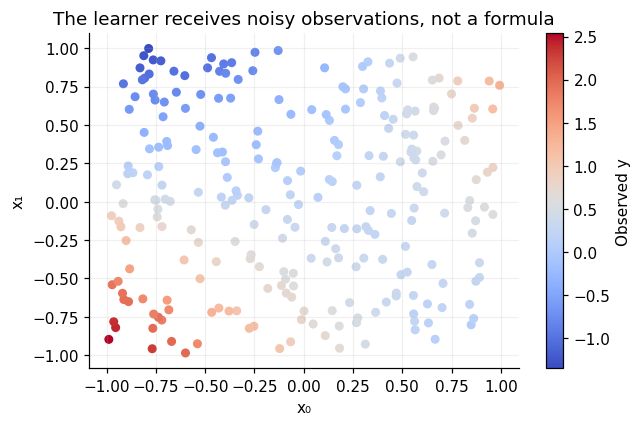

In [6]:
def generating_rule(X):
    x0,x1 = X[:,0],X[:,1]
    return (1.5*x0*x1 + .5*x0**2 - .7*x1 + .2)[:,None]
rng = np.random.default_rng(SEED)
X_train = rng.uniform(-1,1,(256,2)); X_valid = rng.uniform(-1,1,(128,2))
Y_train = generating_rule(X_train) + rng.normal(0,.03,(256,1))
Y_valid = generating_rule(X_valid) + rng.normal(0,.03,(128,1))
fig, ax = plt.subplots(figsize=(6,4))
im = ax.scatter(X_train[:,0],X_train[:,1],c=Y_train[:,0],cmap='coolwarm',s=24)
ax.set(xlabel='x₀',ylabel='x₁',title='The learner receives noisy observations, not a formula')
fig.colorbar(im,ax=ax,label='Observed y'); fig.tight_layout(); plt.show()

## 5 · Fit → shrink → prune → refit

L1 nudges parameters toward zero but ordinary Adam does not reliably produce exact zeros.
We therefore use an explicit pruning step and then freeze the discarded connections.

| Phase | Updates | Action |
|---|---:|---|
| Fit | 800 | Learn a predictive function without L1 |
| Shrink | 1800 | Add L1 with $\lambda=0.003$ |
| Prune | Once | Set penalized parameters with magnitude below $0.05$ to zero |
| Refit | 800 | Remove L1; optimize surviving parameters with the zero mask fixed |

The threshold and schedule are teaching choices fixed before test evaluation. Removing L1
in the final phase reduces shrinkage bias: surviving coefficients can move back toward
values supported by the observations. Pruning is an irreversible choice within a run;
if it deletes an essential connection, refitting cannot restore it.

We use Adam from lesson 00, resetting its moments at each phase boundary. Masks are applied
to parameters after **every** update so momentum cannot revive pruned values. Counts below
are surviving scalar parameters, not mathematical description length. Equivalent expressions
can have different parameter counts and different L1 penalties.

In [7]:
def train(seed, lam=.003, threshold=.05, schedule=(800,1800,800)):
    p = initialize(seed)
    mask = {k:np.ones_like(v) for k,v in p.items()}
    records, snapshots = [], {'initial':{k:v.copy() for k,v in p.items()}}
    update = 0
    for phase, steps, penalty in zip(['fit','shrink','refit'],schedule,[0.,lam,0.]):
        if phase == 'refit':
            snapshots['before pruning'] = {k:v.copy() for k,v in p.items()}
            for k in ['W','b','a']:
                mask[k] = (np.abs(p[k]) >= threshold).astype(float)
                p[k] *= mask[k]
            snapshots['after pruning'] = {k:v.copy() for k,v in p.items()}
        m = {k:np.zeros_like(v) for k,v in p.items()}
        v = {k:np.zeros_like(value) for k,value in p.items()}
        for t in range(1,steps+1):
            _, grads = loss_and_gradients(p,X_train,Y_train,penalty)
            for k in p:
                g = grads[k]*mask[k]
                m[k] = .9*m[k] + .1*g
                v[k] = .999*v[k] + .001*g*g
                p[k] -= .01*(m[k]/(1-.9**t))/(np.sqrt(v[k]/(1-.999**t))+1e-8)
                p[k] *= mask[k]
            update += 1
            if t == 1 or t % 20 == 0 or t == steps:
                records.append([update,half_mse(forward(p,X_train)[0],Y_train),
                                half_mse(forward(p,X_valid)[0],Y_valid),
                                sum(np.count_nonzero(np.abs(p[k])>=threshold) for k in ['W','b','a'])])
        snapshots[phase] = {k:v.copy() for k,v in p.items()}
    assert all(np.isfinite(v).all() for v in p.values())
    for k in p:
        assert np.all(p[k][mask[k]==0] == 0)
    return p,np.array(records),snapshots,mask

# Predetermined seeds, identical budgets; selection never sees test labels.
runs = {seed:train(seed) for seed in [3,7,11]}
valid_scores = {seed:half_mse(forward(run[0],X_valid)[0],Y_valid) for seed,run in runs.items()}
best_seed = min(valid_scores,key=valid_scores.get)
p,history,snapshots,mask = runs[best_seed]
for seed,score in valid_scores.items(): print(f'Seed {seed}: validation half-MSE {score:.6f}')
print('Selected seed:',best_seed)
assert half_mse(forward(p,X_train)[0],Y_train) < half_mse(forward(snapshots['initial'],X_train)[0],Y_train)

Seed 3: validation half-MSE 0.000355
Seed 7: validation half-MSE 0.000354
Seed 11: validation half-MSE 0.000355
Selected seed: 7


fit             train=0.000479 validation=0.000364
before pruning  train=0.000551 validation=0.000482
after pruning   train=0.000551 validation=0.000482
refit           train=0.000471 validation=0.000354


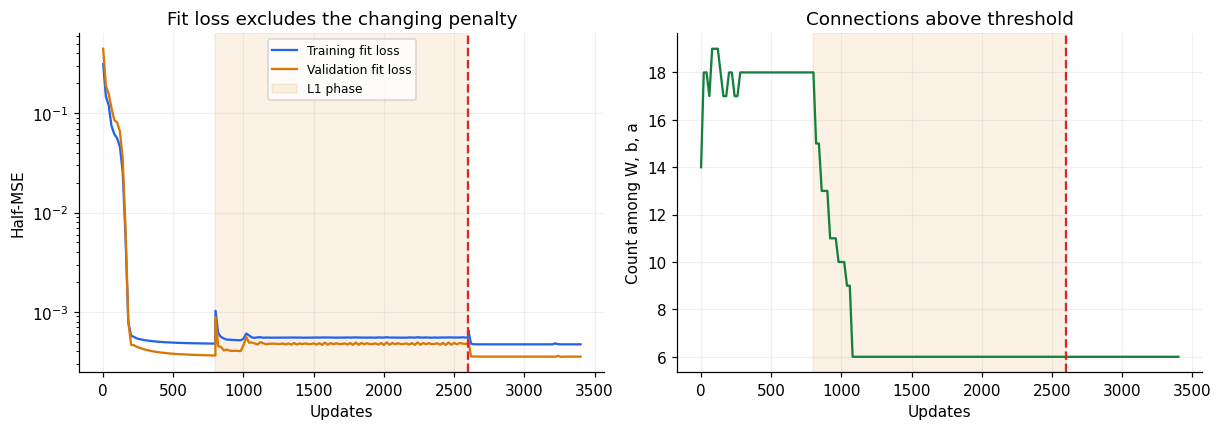

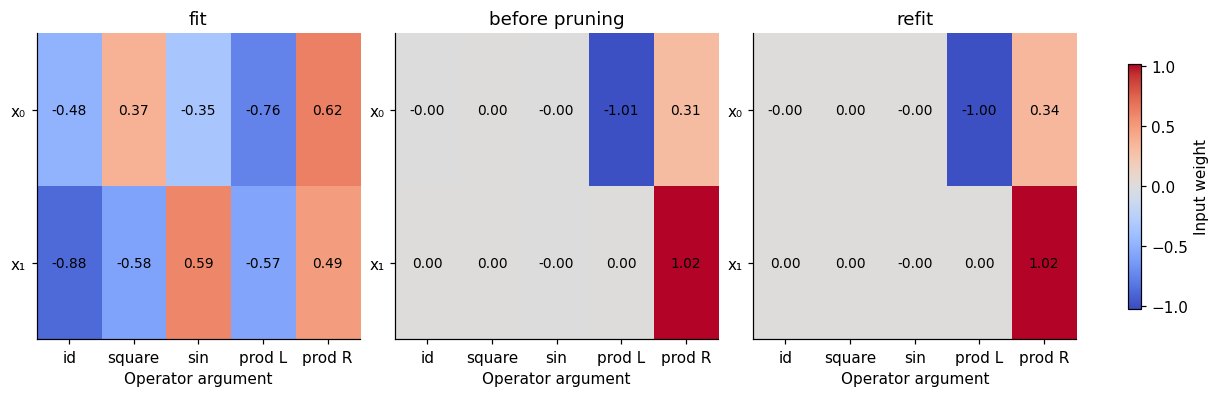

In [8]:
fig, axes = plt.subplots(1,2,figsize=(11,3.8),layout='constrained')
axes[0].semilogy(history[:,0],history[:,1],color=BLUE,label='Training fit loss')
axes[0].semilogy(history[:,0],history[:,2],color=ORANGE,label='Validation fit loss')
axes[1].plot(history[:,0],history[:,3],color=GREEN)
for ax in axes:
    ax.axvspan(800,2600,color=ORANGE,alpha=.10,label='L1 phase' if ax is axes[0] else None)
    ax.axvline(2600,color=RED,ls='--'); ax.set_xlabel('Updates')
axes[0].set(title='Fit loss excludes the changing penalty',ylabel='Half-MSE'); axes[0].legend(fontsize=8)
axes[1].set(title='Connections above threshold',ylabel='Count among W, b, a')
plt.show()
fig, axes = plt.subplots(1,3,figsize=(11,3.5),layout='constrained')
limit=max(np.abs(snapshots[k]['W']).max() for k in ['fit','before pruning','refit'])
for ax,key in zip(axes,['fit','before pruning','refit']):
    im=ax.imshow(snapshots[key]['W'],vmin=-limit,vmax=limit,cmap='coolwarm',aspect='auto')
    ax.set(title=key,xlabel='Operator argument',yticks=[0,1],yticklabels=['x₀','x₁'])
    ax.set_xticks(range(5),['id','square','sin','prod L','prod R']); ax.grid(False)
    for i in range(2):
        for j in range(5): ax.text(j,i,f'{snapshots[key]["W"][i,j]:.2f}',ha='center',va='center',fontsize=9)
fig.colorbar(im,ax=axes,label='Input weight',shrink=.8); plt.show()
for stage in ['fit','before pruning','after pruning','refit']:
    q=snapshots[stage]
    print(f'{stage:15} train={half_mse(forward(q,X_train)[0],Y_train):.6f} '
          f'validation={half_mse(forward(q,X_valid)[0],Y_valid):.6f}')

## 6 · Read the trained network as an expression

We print the expression directly from learned parameters. Display coefficients are rounded;
the actual model retains full precision. No coefficient is replaced with the known answer.

If the sine readout is exactly zero, the remaining network is a quadratic polynomial.
Expanding it into the basis $[1,x_0,x_1,x_0^2,x_0x_1,x_1^2]$ makes its effective coefficients
comparable with the generating rule. This expansion is algebra, not fitting a new model.
If the sine survives, we print it separately and include it when checking predictions.

Raw weights are not uniquely identifiable. For example, multiplying one product argument
by $s\ne0$ and dividing its output coefficient by $s$ gives the same function. Recovering
an equivalent function is different from recovering one specific parameterization.

Learned expression (display rounded):
 -1.4660*(-1.0046*x0 + 0.4662)*(0.3370*x0 + 1.0213*x1 + 0.1555) + 0.3075
Basis:      [constant, x0, x1, x0², x0*x1, x1²]
Polynomial: [ 0.20116 -0.00127 -0.69806  0.49633  1.50414  0.     ]
Reference:  [ 0.2  0.  -0.7  0.5  1.5  0. ]
Sine coefficient: -0.0


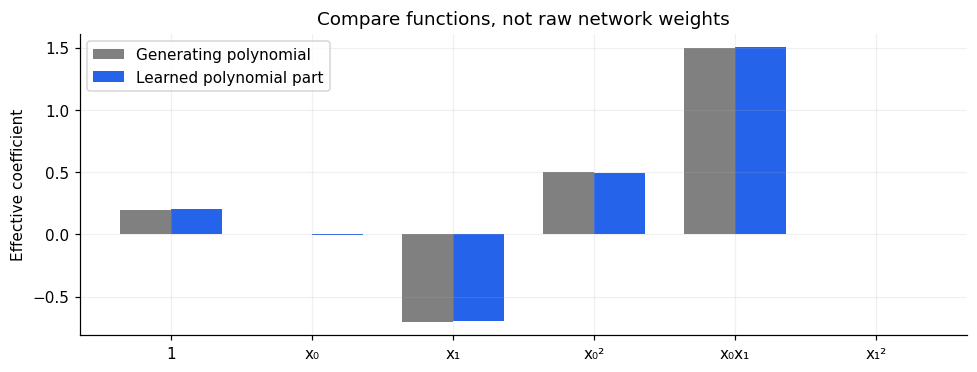

In [9]:
def affine_text(w,b):
    parts=[f'{value:.4f}*{name}' for value,name in zip(w,['x0','x1']) if value != 0]
    if b != 0: parts.append(f'{b:.4f}')
    return '('+' + '.join(parts or ['0'])+')'
def expression_text(p):
    z=[affine_text(p['W'][:,j],p['b'][0,j]) for j in range(5)]
    terms=[z[0],f'{z[1]}**2',f'sin{z[2]}',f'{z[3]}*{z[4]}']
    return ' + '.join([f'{p["a"][j,0]:.4f}*{term}' for j,term in enumerate(terms) if p['a'][j,0] != 0]+[f'{p["c"][0,0]:.4f}'])

def affine_product(u,v):
    # u,v coefficients ordered [constant, x0, x1].
    return np.array([u[0]*v[0],u[0]*v[1]+u[1]*v[0],u[0]*v[2]+u[2]*v[0],
                     u[1]*v[1],u[1]*v[2]+u[2]*v[1],u[2]*v[2]])
def polynomial_coefficients(p):
    args=np.vstack([p['b'],p['W']]).T
    result=np.zeros(6); result[0]=p['c'][0,0]
    result[:3]+=p['a'][0,0]*args[0]
    result+=p['a'][1,0]*affine_product(args[1],args[1])
    result+=p['a'][3,0]*affine_product(args[3],args[4])
    return result

def polynomial_basis(X):
    x0,x1=X.T
    return np.column_stack([np.ones(len(X)),x0,x1,x0*x0,x0*x1,x1*x1])

coeff=polynomial_coefficients(p)
reference=np.array([.2,0.,-.7,.5,1.5,0.])
print('Learned expression (display rounded):\n',expression_text(p))
print('Basis:      [constant, x0, x1, x0², x0*x1, x1²]')
print('Polynomial:',coeff)
print('Reference: ',reference)
print('Sine coefficient:',p['a'][2,0])
# Verify exact algebra with unrounded coefficients at independent points.
X_algebra=np.random.default_rng(99).uniform(-3,3,(50,2))
sine_part=p['a'][2,0]*np.sin(X_algebra@p['W'][:,2]+p['b'][0,2])
np.testing.assert_allclose(polynomial_basis(X_algebra)@coeff+sine_part,
                           forward(p,X_algebra)[0][:,0],rtol=1e-10,atol=1e-10)
fig,ax=plt.subplots(figsize=(9,3.5)); pos=np.arange(6)
ax.bar(pos-.18,reference,.36,label='Generating polynomial',color='grey')
ax.bar(pos+.18,coeff,.36,label='Learned polynomial part',color=BLUE)
ax.set_xticks(pos,['1','x₀','x₁','x₀²','x₀x₁','x₁²']); ax.set(ylabel='Effective coefficient',title='Compare functions, not raw network weights')
ax.legend(); fig.tight_layout(); plt.show()

### Read the result before moving on

In the saved run, pruning removes the identity, square, and sine readouts. The surviving
product of two affine expressions still produces a square term, an interaction, linear
terms, and a constant when expanded. An explicit square slot is therefore unnecessary
for this particular learned factorization.

The recovered polynomial is approximately
$0.20116-0.00127x_0-0.69806x_1+0.49633x_0^2+1.50414x_0x_1$.
This is close to the generating rule, not an exact recovery. Small discrepancies reflect
the finite noisy sample and numerical fitting. Other seeds or settings can produce a
different expression; use the printed output after your own changes.

## 7 · Freeze the choice, then inspect generalization

Now evaluate the selected model on new noisy in-domain examples and a separate noiseless
extrapolation diagnostic in $[-2,2]^2\setminus[-1,1]^2$. We report these separately because
both the input distribution and presence of observation noise differ.

A fixed quadratic least-squares baseline is also included. It has the exact polynomial
basis used by the synthetic generator, so this is a deliberately favorable baseline.
For this problem, solving a six-coefficient linear system can be more direct than training
an EQL. The baseline's advantage is prior structural knowledge, not a universal ranking.

**Predict:** what happens if the EQL keeps a sine term that imitates a line only near zero?
Remember that our model selection used in-domain validation, which need not distinguish
models that disagree outside the observed domain.

EQL: noisy in-domain test=0.000488; noiseless extrapolation=0.000048
Quadratic least squares: noisy in-domain test=0.000489; noiseless extrapolation=0.000044


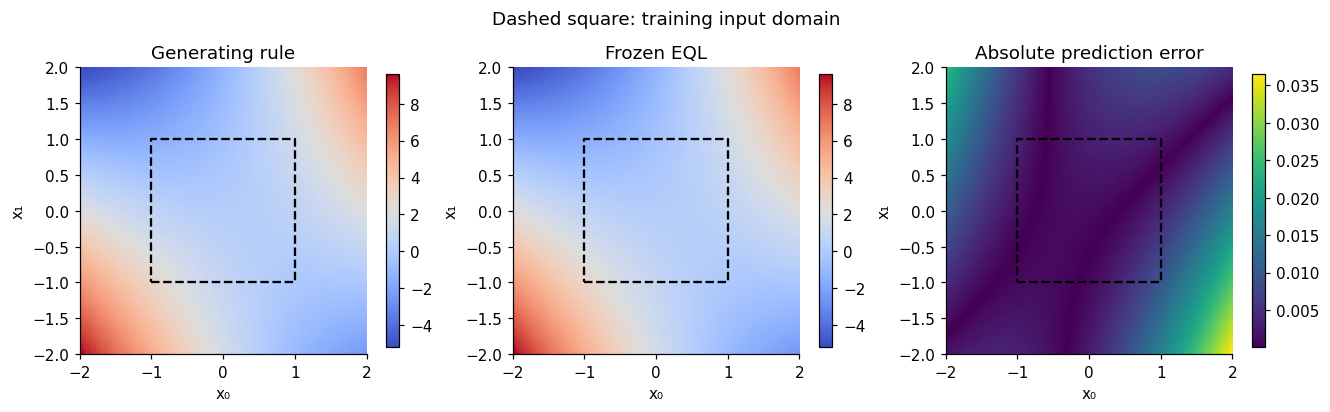

In [10]:
baseline_coeff=np.linalg.lstsq(polynomial_basis(X_train),Y_train,rcond=None)[0]
rng_test=np.random.default_rng(2026)
X_test=rng_test.uniform(-1,1,(256,2))
Y_test=generating_rule(X_test)+rng_test.normal(0,.03,(256,1))
wide=rng_test.uniform(-2,2,(2000,2)); X_out=wide[np.any(np.abs(wide)>1,axis=1)]
Y_out=generating_rule(X_out)
for name, predict in [('EQL',lambda X:forward(p,X)[0]),('Quadratic least squares',lambda X:polynomial_basis(X)@baseline_coeff)]:
    print(f'{name}: noisy in-domain test={half_mse(predict(X_test),Y_test):.6f}; '
          f'noiseless extrapolation={half_mse(predict(X_out),Y_out):.6f}')
grid=np.linspace(-2,2,90); xx,yy=np.meshgrid(grid,grid); X_grid=np.column_stack([xx.ravel(),yy.ravel()])
truth=generating_rule(X_grid).reshape(xx.shape); prediction=forward(p,X_grid)[0].reshape(xx.shape)
fig,axes=plt.subplots(1,3,figsize=(12,3.7),layout='constrained')
for ax,data,title in zip(axes,[truth,prediction,np.abs(prediction-truth)],['Generating rule','Frozen EQL','Absolute prediction error']):
    im=ax.imshow(data,extent=(-2,2,-2,2),origin='lower',cmap='viridis' if 'error' in title else 'coolwarm',
                 **({} if 'error' in title else {'vmin':truth.min(),'vmax':truth.max()}))
    ax.plot([-1,1,1,-1,-1],[-1,-1,1,1,-1],'k--',lw=1.5)
    ax.set(title=title,xlabel='x₀',ylabel='x₁'); ax.grid(False); fig.colorbar(im,ax=ax,shrink=.8)
fig.suptitle('Dashed square: training input domain'); plt.show()

## 8 · Why sparsity does not guarantee truth

Three distinct issues remain even when the code is correct.

**Identifiability:** finite observations can support multiple rules. On a narrow interval,
$\sin x\approx x$; outside it, they disagree. Noise makes the distinction harder.
Even exact function equivalence need not give unique network weights.

**Grammar mismatch:** a finite polynomial basis cannot exactly equal $\sin x$ for all real
$x$. More optimization cannot fix that function-class restriction. Operator choice and
layer depth matter before training begins.

**Optimization and scale:** our objective is nonconvex, and different initializations can
find different solutions. L1 depends on parameterization and units. Standardizing input data
changes the coordinates of the recovered equation: substitute the inverse scaling before
interpreting coefficients in physical units. Products of quantities must respect units;
sine arguments should be dimensionless. This notebook uses dimensionless inputs.

The next figure is an analytic illustration, not an additional fitted or selected model.

Product rescaling changes parameters while preserving predictions.


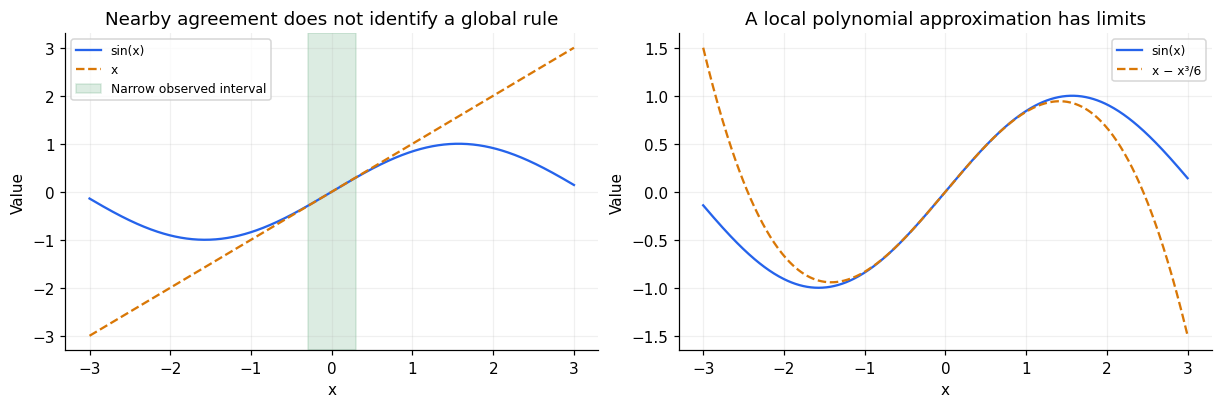

In [11]:
t=np.linspace(-3,3,500)
fig,axes=plt.subplots(1,2,figsize=(11,3.6),layout='constrained')
axes[0].plot(t,np.sin(t),color=BLUE,label='sin(x)'); axes[0].plot(t,t,'--',color=ORANGE,label='x')
axes[0].axvspan(-.3,.3,color=GREEN,alpha=.15,label='Narrow observed interval')
axes[0].set(title='Nearby agreement does not identify a global rule',xlabel='x',ylabel='Value'); axes[0].legend(fontsize=8)
axes[1].plot(t,np.sin(t),color=BLUE,label='sin(x)')
axes[1].plot(t,t-t**3/6,'--',color=ORANGE,label='x − x³/6')
axes[1].set(title='A local polynomial approximation has limits',xlabel='x',ylabel='Value'); axes[1].legend(fontsize=8)
plt.show()
# Demonstrate a symmetry of the learned product branch.
rescaled={k:v.copy() for k,v in p.items()}
rescaled['W'][:,3]*=2; rescaled['b'][:,3]*=2; rescaled['a'][3]/=2
np.testing.assert_allclose(forward(rescaled,X_algebra)[0],forward(p,X_algebra)[0],atol=1e-12)
print('Product rescaling changes parameters while preserving predictions.')

## 9 · Where this connects to your symbolic search work

EQL makes continuous optimization work *inside an operator graph*. Your symbolic/ARC work
also needs choices about structure: which operation to apply, which object to use, how to
compose steps, and how to score candidate programs. Many of those choices are discrete,
so this backward pass cannot directly differentiate through them.

Useful transfers are the operator interface, exact forward semantics, invariant checks,
complexity control, and the distinction between matching examples and discovering a rule.
An eventual hybrid might search discrete structures and fit their continuous constants,
or learn a policy that prioritizes promising structures. This notebook is a foundation
for those ideas, not an ARC solver or evidence of a business-ready scientific discovery tool.

**Why no division here?** For $u/v$, derivatives $1/v$ and $-u/v^2$ become large near zero.
Adding a tiny epsilon changes the function and does not solve domain validity in general.
EQL-Div studies dedicated handling; add domain constraints and numerical checks before
experimenting with that operator.

## 10 · Exercises: stop before the solutions

1. **Derive a product gradient.** If $h=z_3z_4$, $z_3=-2$, $z_4=3$, and the incoming
   sensitivity is $0.5$, calculate both input sensitivities. What if both arguments are zero?
2. **Add cosine.** Specify the new matrix shapes, forward column, and backward derivative
   needed to add a cosine slot while keeping the current four outputs.
3. **Ablate sparsity.** Train the same seed with `lam=0, threshold=0`. Compare validation
   loss, surviving terms, and expression length with the sparse run. This is a new experiment;
   do not claim its test performance is an untouched final test after inspecting it repeatedly.
4. **Break the grammar.** Remove sine and try a sine-generating target over a wide interval.
   Before running, identify which polynomial degree our remaining one-layer network can represent.
5. **Change coordinates.** If a fitted expression in standardized variables is $2uv+1$, where
   $u=(x-10)/2$ and $v=(z-5)/4$, express it in the original units.
6. **Challenge the discovery.** Replace broad two-dimensional training coverage with examples
   near $x_1=x_0$. Why can recovering the separate $x_0^2$ and $x_0x_1$ coefficients become difficult?

Try changing one thing at a time and record a prediction, observation, and explanation.

## 11 · Solutions and reasoning

1. The sensitivities are $d z_3=0.5(3)=1.5$ and $d z_4=0.5(-2)=-1$.
   With both arguments zero, both sensitivities vanish. This is one reason not to initialize
   every product argument to zero.
2. Add a sixth affine argument: $W:2\times6$, $b:1\times6$. Append $\cos(z_5)$ to make
   $H:N\times5$, extend $a$ to $5\times1$, and use $d z_5=-\sin(z_5)G_4$.
   Extend the expression renderer too, then rerun numerical checks. Existing slots keep their indices.
3. The unregularized model may achieve similar validation loss with more nonzero terms.
   Alternatively, pruning can worsen prediction by deleting a needed connection. Neither outcome
   is guaranteed. Compare actual expressions, not only small raw coefficients.
4. An affine readout of affine terms, squared affine terms, and products of affine terms has
   degree at most two. It cannot globally represent a sine function. A small fit error over a
   short range would not contradict this restriction.
5. $2uv+1=(x-10)(z-5)/4+1=0.25xz-1.25x-2.5z+13.5$.
6. On the exact diagonal, $x_0x_1=x_0^2$. Observations constrain their sum of coefficients,
   not the individual coefficients. More diverse input coverage can distinguish them; L1 alone
   cannot create information missing from the experiment.

## 12 · Reconstruct it without looking

You should be able to draw the five affine arguments and four operator outputs, derive
the product gradients, explain the three training phases, export the expression, and
state why low error is insufficient evidence of unique equation recovery.

**Vocabulary:** *symbolic regression* searches mathematical expressions that fit observations;
*operator grammar* defines allowed building blocks; *sparsity* means many connections are zero;
*pruning* explicitly removes connections; *identifiability* concerns whether observations can
distinguish candidate models; *extrapolation* predicts outside the observed input domain.

### Primary sources and implementation scope

- Martius and Lampert, [Extrapolation and learning equations (2016 preprint)](https://arxiv.org/abs/1610.02995).
- Sahoo, Lampert, and Martius, [Learning Equations for Extrapolation and Control (ICML 2018)](https://proceedings.mlr.press/v80/sahoo18a.html).
- [Authors' EQL implementation](https://github.com/martius-lab/EQL).

The historical overview follows these works. Our data, plots, NumPy code, square operator,
training settings, validation-only selection rule, and polynomial baseline are original teaching
choices, not the authors' experimental protocol. This small example is not a benchmark of modern
symbolic regression. All figures are generated by the included code.

**Next: 02 — programs as hypotheses, typed grammars, and a small interpreter.**